# 🌐 Website Traffic Analysis

**Author:** Reha Arif
**Project type:** Data Analysis (Exploratory Data Analysis + Insights)

This notebook analyzes website traffic data spanning traffic sources, page-level
performance, user engagement, and conversions. The goal is to identify what
drives conversions and high bounce rates, and to surface actionable insights
for improving traffic quality and site performance.

**Dataset columns:**
| Column | Description |
|---|---|
| `record_id` | Unique row identifier |
| `date` | Date of the traffic record |
| `traffic_source` | Organic Search / Paid Search / Referral / Social / Direct |
| `page_url` | Page path the traffic landed on |
| `sessions` | Number of sessions |
| `users` | Number of unique users |
| `bounce_rate` | Share of single-page sessions (0-1) |
| `session_duration` | Average session duration (seconds) |
| `pages_per_session` | Average pages viewed per session |
| `conversions` | Number of conversion events |
| `goal_completions` | Number of goal completions (incl. micro-conversions) |

---


## 1. Import Libraries

We import the core data-analysis and visualization stack: `pandas` and `numpy` for data handling, `matplotlib` and `seaborn` for visualization.

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Notebook / display settings
%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("Libraries imported successfully.")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully.
Pandas version: 3.0.2
NumPy version: 2.4.4


## 2. Load Dataset

We load `website_traffic.csv` — a daily, source- and page-level traffic export
(similar in grain to a Google Analytics export). 

In [2]:
# Load the dataset
df = pd.read_csv("website_traffic.csv")

# Preview the first few rows
df.head(10)

,record_id,date,traffic_source,page_url,sessions,users,bounce_rate,session_duration,pages_per_session,conversions,goal_completions
0,12425,2026-03-21,Direct,/product/running-shoes,5,4,0.2828,240.0,2.74,0.0,0
1,13624,2026-04-14,Direct,/blog/summer-sale-guide,8,7,0.4845,214.0,2.58,0.0,0
2,14018,2026-04-22,Social,/checkout,3,3,0.4706,181.6,3.04,0.0,0
3,16983,2026-06-21,Paid Search,/about-us,10,9,0.5258,95.3,2.17,1.0,1
4,10903,2026-02-19,Organic Search,/checkout,5,5,0.1617,178.2,3.31,1.0,1
5,14777,2026-05-07,Direct,/checkout,3,3,0.2636,240.8,3.36,0.0,0
6,17546,2026-07-02,Social,/product/backpacks,6,6,0.6330,163.8,1.24,0.0,0
7,18369,2026-07-19,Organic Search,/pricing,16,15,0.4012,211.0,2.76,0.0,1
8,12816,2026-03-29,Social,/blog/how-to-choose-running-shoes,4,3,0.7594,145.8,1.00,0.0,0
9,16854,2026-06-18,Social,/contact,10,9,0.8460,59.1,1.00,0.0,0


In [3]:
# Shape of the dataset (rows, columns)
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset shape: 9033 rows, 11 columns


In [4]:
# Structure, dtypes, and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9033 entries, 0 to 9032
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   record_id          9033 non-null   int64  
 1   date               9033 non-null   str    
 2   traffic_source     9033 non-null   str    
 3   page_url           9033 non-null   str    
 4   sessions           9033 non-null   int64  
 5   users              9033 non-null   int64  
 6   bounce_rate        8853 non-null   float64
 7   session_duration   8852 non-null   float64
 8   pages_per_session  8851 non-null   float64
 9   conversions        8853 non-null   float64
 10  goal_completions   9033 non-null   int64  
dtypes: float64(4), int64(4), str(3)
memory usage: 776.4 KB


In [5]:
# Quick statistical summary of numeric columns
df.describe()

,record_id,sessions,users,bounce_rate,session_duration,pages_per_session,conversions,goal_completions
count,9033.000000,9033.00000,9033.000000,8853.000000,8852.000000,8851.000000,8853.000000,9033.000000
mean,14502.410716,12.14602,10.893723,0.587679,183.252269,2.371360,0.516435,0.713274
std,2600.631309,9.14055,8.186610,5.305103,63.265444,0.752097,0.854592,1.063286
min,10001.000000,-5.00000,1.000000,-0.100000,-91.392204,1.000000,0.000000,0.000000
25%,12252.000000,6.00000,5.000000,0.363900,139.375000,1.820000,0.000000,0.000000
50%,14501.000000,10.00000,9.000000,0.470800,189.350000,2.380000,0.000000,0.000000
75%,16754.000000,16.00000,14.000000,0.580700,230.000000,2.910000,1.000000,1.000000
max,19008.000000,71.00000,68.000000,250.000000,371.200000,4.980000,8.000000,9.000000


## 3. Data Cleaning

Web analytics exports commonly contain: missing metric values, duplicate
rows, invalid/out-of-range values (e.g., negative sessions, bounce rates over
100%), inconsistent date string formats, and mixed data types. We handle each
issue below.

### 3.1 Check for missing values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_pct
bounce_rate,180,1.99
session_duration,181,2.00
pages_per_session,182,2.01
conversions,180,1.99


### 3.2 Check and remove duplicate rows

In [7]:
duplicate_count = df.duplicated().sum()
print(f"Number of exact duplicate rows: {duplicate_count}")

# Drop duplicates, keep the first occurrence
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")

Number of exact duplicate rows: 25
Shape after removing duplicates: (9008, 11)


### 3.3 Parse and standardize the date column

The raw `date` column contains multiple inconsistent formats (e.g. `21/03/2026`, `03-21-2026`, `March 21, 2026`). We parse all of them into a single, consistent `datetime` type.

In [8]:
# Preview a few raw date formats present in the data
df['date'].sample(10, random_state=1).tolist()

['2026-03-18',
 '2026-07-18',
 '2026-06-11',
 '2026-06-25',
 '2026-03-11',
 '2026-07-16',
 '2026-02-12',
 '2026-06-24',
 '2026-02-20',
 '2026-02-08']

In [9]:
# Robust parsing: try known explicit formats first, then fall back to flexible parsing
def parse_date(value):
    for fmt in ("%Y-%m-%d", "%d/%m/%Y", "%m-%d-%Y", "%B %d, %Y", "%Y/%m/%d"):
        try:
            return pd.to_datetime(value, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.to_datetime(value, errors='coerce')  # last-resort flexible parse

df['date'] = df['date'].apply(parse_date)

print("Unparseable dates remaining:", df['date'].isnull().sum())
print("Date range:", df['date'].min(), "to", df['date'].max())
df['date'].head()

Unparseable dates remaining: 0
Date range: 2026-02-01 00:00:00 to 2026-07-31 00:00:00


0   2026-03-21
1   2026-04-14
2   2026-04-22
3   2026-06-21
4   2026-02-19
Name: date, dtype: datetime64[us]

### 3.4 Fix data types

`pages_per_session` was stored as text in a few rows (mixed dtype), and `conversions` should be an integer count.

In [ ]:
# Force pages_per_session to numeric; invalid parses become NaN
df['pages_per_session'] = pd.to_numeric(df['pages_per_session'], errors='coerce')

# Confirm dtypes
df.dtypes

record_id                     int64
date                 datetime64[us]
traffic_source                  str
page_url                        str
sessions                      int64
users                         int64
bounce_rate                 float64
session_duration            float64
pages_per_session           float64
conversions                 float64
goal_completions              int64
dtype: object

### 3.5 Clean invalid / out-of-range values

`bounce_rate` must be between 0 and 1, and `sessions` / `session_duration` cannot be negative. Values outside valid bounds are treated as data errors and converted to missing, to be imputed next.

In [11]:
# Flag out-of-range / invalid values as NaN
df.loc[(df['bounce_rate'] < 0) | (df['bounce_rate'] > 1), 'bounce_rate'] = np.nan
df.loc[df['sessions'] < 0, 'sessions'] = np.nan
df.loc[df['session_duration'] < 0, 'session_duration'] = np.nan

print("Invalid values converted to NaN:")
print(df[['bounce_rate', 'sessions', 'session_duration']].isnull().sum())

Invalid values converted to NaN:
bounce_rate         188
sessions              5
session_duration    185
dtype: int64


### 3.6 Standardize text columns

Trim whitespace and normalize casing in `traffic_source`.

In [12]:
df['traffic_source'] = df['traffic_source'].astype(str).str.strip().str.title()
df['page_url'] = df['page_url'].astype(str).str.strip()

print("Unique traffic sources after cleaning:", df['traffic_source'].unique())

Unique traffic sources after cleaning: <StringArray>
['Direct', 'Social', 'Paid Search', 'Organic Search', 'Referral']
Length: 5, dtype: str


### 3.7 Handle missing numeric values

Missing `sessions` rows (invalid entries) are dropped since sessions is the core metric that cannot be reliably imputed. Missing `bounce_rate`, `session_duration`, `pages_per_session`, and `conversions` are imputed using the source + page group median, which best reflects typical behavior for that traffic-source/page combination.

In [13]:
# Drop rows where sessions itself is missing/invalid (can't be meaningfully imputed)
before_rows = len(df)
df = df.dropna(subset=['sessions']).reset_index(drop=True)
print(f"Dropped {before_rows - len(df)} rows with invalid/missing sessions.")

# Impute remaining metrics using the (traffic_source, page_url) group median
for col in ['bounce_rate', 'session_duration', 'pages_per_session', 'conversions']:
    df[col] = df.groupby(['traffic_source', 'page_url'])[col].transform(lambda x: x.fillna(x.median()))
    df[col] = df[col].fillna(df[col].median())  # fallback for any still-missing groups

print("Remaining missing values:\n", df.isnull().sum())

Dropped 5 rows with invalid/missing sessions.
Remaining missing values:
 record_id            0
date                 0
traffic_source       0
page_url             0
sessions             0
users                0
bounce_rate          0
session_duration     0
pages_per_session    0
conversions          0
goal_completions     0
dtype: int64


In [14]:
# Final type & rounding cleanup
df['sessions'] = df['sessions'].astype(int)
df['users'] = df['users'].astype(int)
df['conversions'] = df['conversions'].round().astype(int)
df['goal_completions'] = df['goal_completions'].astype(int)
df['bounce_rate'] = df['bounce_rate'].round(4)
df['session_duration'] = df['session_duration'].round(1)
df['pages_per_session'] = df['pages_per_session'].round(2)

print(f"Final cleaned dataset shape: {df.shape}")
df.head()

Final cleaned dataset shape: (9003, 11)


,record_id,date,traffic_source,page_url,sessions,users,bounce_rate,session_duration,pages_per_session,conversions,goal_completions
0,12425,2026-03-21,Direct,/product/running-shoes,5,4,0.2828,240.0,2.74,0,0
1,13624,2026-04-14,Direct,/blog/summer-sale-guide,8,7,0.4845,214.0,2.58,0,0
2,14018,2026-04-22,Social,/checkout,3,3,0.4706,181.6,3.04,0,0
3,16983,2026-06-21,Paid Search,/about-us,10,9,0.5258,95.3,2.17,1,1
4,10903,2026-02-19,Organic Search,/checkout,5,5,0.1617,178.2,3.31,1,1


## 4. Exploratory Data Analysis (EDA)

### 4.1 Overall traffic trend over time (daily & monthly)

In [15]:
daily_traffic = df.groupby('date')['sessions'].sum().sort_index()
monthly_traffic = df.groupby(df['date'].dt.to_period('M'))['sessions'].sum()

print("Daily sessions - first 5 days:")
print(daily_traffic.head())
print("\nMonthly sessions:")
print(monthly_traffic)

Daily sessions - first 5 days:
date
2026-02-01    425
2026-02-02    529
2026-02-03    516
2026-02-04    552
2026-02-05    569
Name: sessions, dtype: int64

Monthly sessions:
date
2026-02    14425
2026-03    16645
2026-04    20682
2026-05    18248
2026-06    19023
2026-07    20440
Freq: M, Name: sessions, dtype: int64


### 4.2 Traffic source breakdown (organic vs paid vs referral vs social vs direct)

In [16]:
source_breakdown = df.groupby('traffic_source').agg(
    total_sessions=('sessions', 'sum'),
    total_users=('users', 'sum'),
    avg_bounce_rate=('bounce_rate', 'mean'),
    total_conversions=('conversions', 'sum')
).round(3).sort_values('total_sessions', ascending=False)

source_breakdown['session_share_pct'] = (source_breakdown['total_sessions'] / source_breakdown['total_sessions'].sum() * 100).round(2)
source_breakdown

,total_sessions,total_users,avg_bounce_rate,total_conversions,session_share_pct
traffic_source,,,,,
Organic Search,38856,34798,0.452,1652,35.50
Paid Search,22703,20365,0.511,1270,20.74
Social,18584,16633,0.612,391,16.98
Direct,15730,14089,0.379,736,14.37
Referral,13590,12209,0.421,549,12.42


### 4.3 User engagement analysis (session duration, pages/session by source)

In [17]:
engagement_by_source = df.groupby('traffic_source').agg(
    avg_session_duration=('session_duration', 'mean'),
    avg_pages_per_session=('pages_per_session', 'mean'),
    avg_bounce_rate=('bounce_rate', 'mean')
).round(2).sort_values('avg_session_duration', ascending=False)

engagement_by_source

,avg_session_duration,avg_pages_per_session,avg_bounce_rate
traffic_source,,,
Direct,233.41,2.80,0.38
Referral,213.12,2.60,0.42
Organic Search,199.11,2.46,0.45
Paid Search,163.30,2.20,0.51
Social,108.05,1.79,0.61


### 4.4 Conversion rate analysis by traffic source and by page

In [18]:
# Conversion rate by source = total conversions / total sessions
conv_by_source = df.groupby('traffic_source').apply(
    lambda g: pd.Series({
        'total_sessions': g['sessions'].sum(),
        'total_conversions': g['conversions'].sum(),
        'conversion_rate_pct': round(g['conversions'].sum() / g['sessions'].sum() * 100, 2)
    }),
    include_groups=False
).sort_values('conversion_rate_pct', ascending=False)

conv_by_source

,total_sessions,total_conversions,conversion_rate_pct
traffic_source,,,
Paid Search,22703.0,1270.0,5.59
Direct,15730.0,736.0,4.68
Organic Search,38856.0,1652.0,4.25
Referral,13590.0,549.0,4.04
Social,18584.0,391.0,2.10


In [19]:
# Conversion rate by page
conv_by_page = df.groupby('page_url').apply(
    lambda g: pd.Series({
        'total_sessions': g['sessions'].sum(),
        'total_conversions': g['conversions'].sum(),
        'conversion_rate_pct': round(g['conversions'].sum() / g['sessions'].sum() * 100, 2)
    }),
    include_groups=False
).sort_values('conversion_rate_pct', ascending=False)

conv_by_page

,total_sessions,total_conversions,conversion_rate_pct
page_url,,,
/checkout,4536.0,442.0,9.74
/pricing,7676.0,453.0,5.90
/product/running-shoes,16793.0,920.0,5.48
/product/winter-jackets,12268.0,625.0,5.09
/product/backpacks,8857.0,445.0,5.02
/home,22328.0,883.0,3.95
/blog/how-to-choose-running-shoes,13576.0,359.0,2.64
/blog/summer-sale-guide,11270.0,237.0,2.10
/about-us,6712.0,133.0,1.98


### 4.5 High-performing vs low-performing pages

In [20]:
page_summary = df.groupby('page_url').agg(
    total_sessions=('sessions', 'sum'),
    avg_bounce_rate=('bounce_rate', 'mean'),
    avg_session_duration=('session_duration', 'mean'),
    total_conversions=('conversions', 'sum')
)
page_summary['conversion_rate_pct'] = (page_summary['total_conversions'] / page_summary['total_sessions'] * 100).round(2)
page_summary = page_summary.round(2).sort_values('conversion_rate_pct', ascending=False)

print("Top 5 high-performing pages (by conversion rate):")
display(page_summary.head(5))

print("\nBottom 5 low-performing pages (by conversion rate):")
display(page_summary.tail(5).sort_values('conversion_rate_pct'))

Top 5 high-performing pages (by conversion rate):

,total_sessions,avg_bounce_rate,avg_session_duration,total_conversions,conversion_rate_pct
page_url,,,,,
/checkout,4536,0.29,209.70,442,9.74
/pricing,7676,0.36,195.54,453,5.90
/product/running-shoes,16793,0.42,191.50,920,5.48
/product/winter-jackets,12268,0.43,184.71,625,5.09
/product/backpacks,8857,0.44,180.46,445,5.02



Bottom 5 low-performing pages (by conversion rate):


,total_sessions,avg_bounce_rate,avg_session_duration,total_conversions,conversion_rate_pct
page_url,,,,,
/contact,5447,0.65,109.21,101,1.85
/about-us,6712,0.54,139.34,133,1.98
/blog/summer-sale-guide,11270,0.62,213.66,237,2.10
/blog/how-to-choose-running-shoes,13576,0.60,229.55,359,2.64
/home,22328,0.39,178.34,883,3.95


## 5. Visualizations

Standard chart types: line chart (traffic trend), bar chart (source-wise
sessions), pie chart (traffic source share), and a correlation heatmap.

### 5.1 Line chart — Daily traffic trend over time

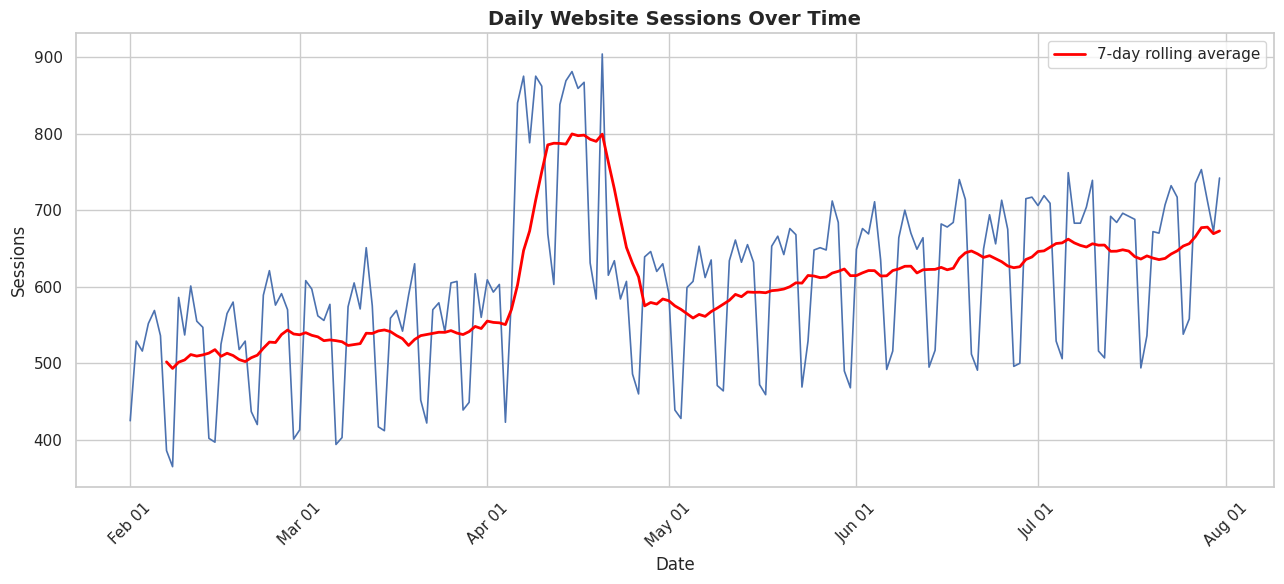

In [21]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(daily_traffic.index, daily_traffic.values, color='#4C72B0', linewidth=1.2)

# 7-day rolling average to smooth day-to-day noise
rolling_avg = daily_traffic.rolling(7).mean()
ax.plot(rolling_avg.index, rolling_avg.values, color='red', linewidth=2, label='7-day rolling average')

ax.set_title('Daily Website Sessions Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Sessions')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5.2 Bar chart — Source-wise total sessions

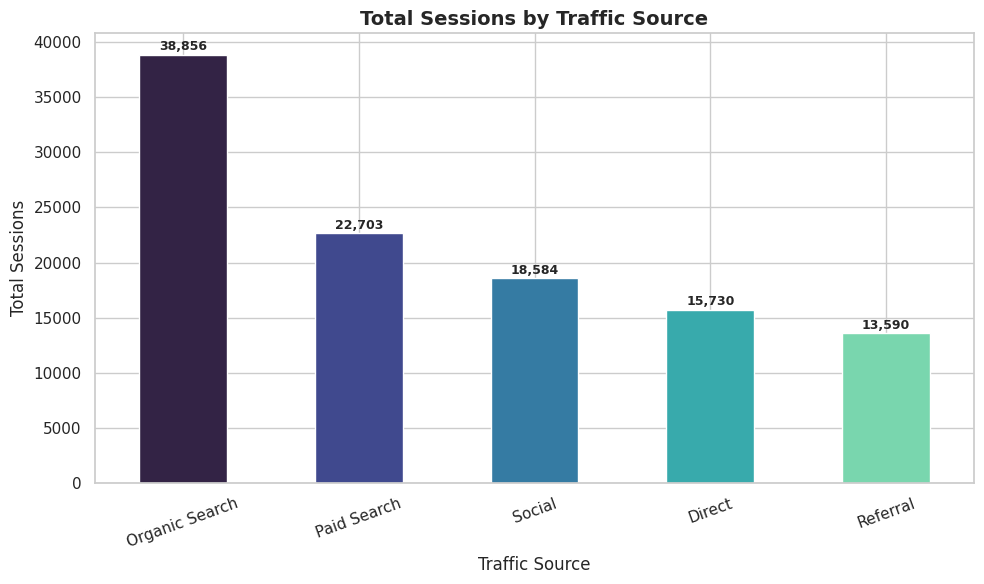

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
source_sessions = df.groupby('traffic_source')['sessions'].sum().sort_values(ascending=False)
source_sessions.plot(kind='bar', color=sns.color_palette('mako', len(source_sessions)), ax=ax)
ax.set_title('Total Sessions by Traffic Source')
ax.set_xlabel('Traffic Source')
ax.set_ylabel('Total Sessions')
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(source_sessions):
    ax.text(i, v + max(source_sessions) * 0.01, f"{v:,}", ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

### 5.3 Pie chart — Traffic source share

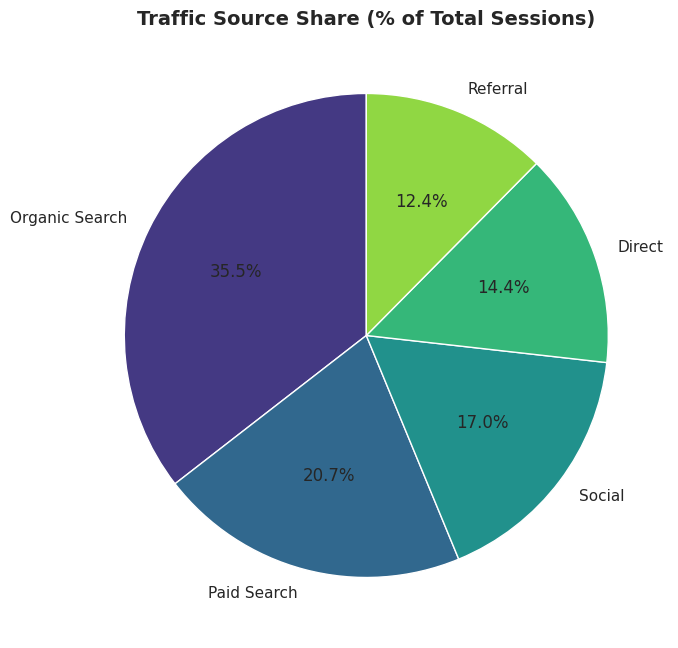

In [23]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(source_sessions, labels=source_sessions.index, autopct='%1.1f%%', startangle=90,
       colors=sns.color_palette('viridis', len(source_sessions)), wedgeprops={'edgecolor': 'white'})
ax.set_title('Traffic Source Share (% of Total Sessions)')
plt.tight_layout()
plt.show()

### 5.4 Heatmap — Correlation between bounce rate, duration, pages/session, and conversions

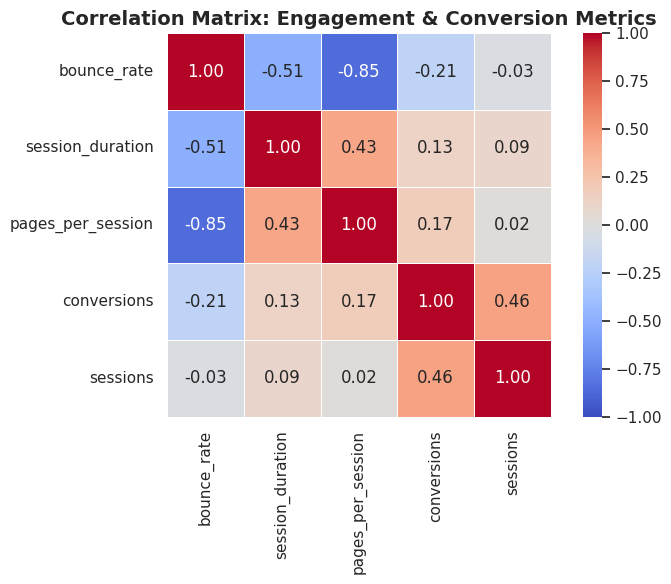

,bounce_rate,session_duration,pages_per_session,conversions,sessions
bounce_rate,1.000000,-0.505059,-0.852058,-0.206727,-0.027239
session_duration,-0.505059,1.000000,0.432531,0.125442,0.093950
pages_per_session,-0.852058,0.432531,1.000000,0.174262,0.020511
conversions,-0.206727,0.125442,0.174262,1.000000,0.457624
sessions,-0.027239,0.093950,0.020511,0.457624,1.000000


In [24]:
numeric_cols = df[['bounce_rate', 'session_duration', 'pages_per_session', 'conversions', 'sessions']]
corr_matrix = numeric_cols.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix: Engagement & Conversion Metrics')
plt.tight_layout()
plt.show()

corr_matrix

## 6. Key Factors Driving Conversions and High Bounce Rates

We quantify which metrics are most associated with conversions and with bounce
rate using correlation strength, plus a direct comparison across traffic
sources and page types.

In [25]:
# Correlation strength ranking against conversions
conv_correlations = corr_matrix['conversions'].drop('conversions').abs().sort_values(ascending=False)
print("Factors ranked by correlation strength with conversions:")
print(conv_correlations)

print()
# Correlation strength ranking against bounce_rate
bounce_correlations = corr_matrix['bounce_rate'].drop('bounce_rate').abs().sort_values(ascending=False)
print("Factors ranked by correlation strength with bounce rate:")
print(bounce_correlations)

Factors ranked by correlation strength with conversions:
sessions             0.457624
bounce_rate          0.206727
pages_per_session    0.174262
session_duration     0.125442
Name: conversions, dtype: float64

Factors ranked by correlation strength with bounce rate:
pages_per_session    0.852058
session_duration     0.505059
conversions          0.206727
sessions             0.027239
Name: bounce_rate, dtype: float64


In [26]:
# Compare conversion rate: low-bounce vs high-bounce sessions (session-weighted)
bounce_median = df['bounce_rate'].median()
low_bounce = df[df['bounce_rate'] <= bounce_median]
high_bounce = df[df['bounce_rate'] > bounce_median]

low_bounce_conv_rate = low_bounce['conversions'].sum() / low_bounce['sessions'].sum() * 100
high_bounce_conv_rate = high_bounce['conversions'].sum() / high_bounce['sessions'].sum() * 100

print(f"Conversion rate - Low bounce-rate group: {low_bounce_conv_rate:.2f}%")
print(f"Conversion rate - High bounce-rate group: {high_bounce_conv_rate:.2f}%")

Conversion rate - Low bounce-rate group: 5.41%
Conversion rate - High bounce-rate group: 2.83%


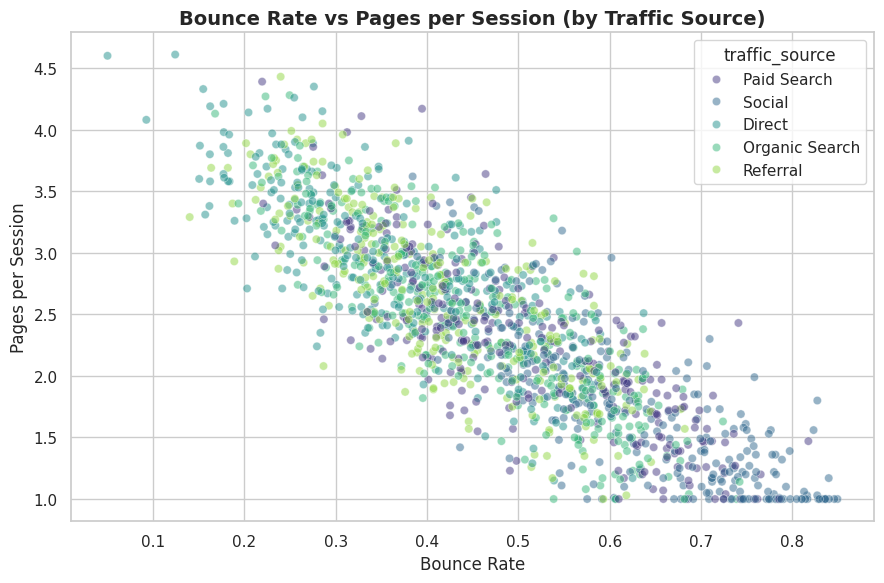

In [27]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=df.sample(min(1500, len(df)), random_state=1),
                 x='bounce_rate', y='pages_per_session', hue='traffic_source',
                 alpha=0.5, ax=ax, palette='viridis')
ax.set_title('Bounce Rate vs Pages per Session (by Traffic Source)')
ax.set_xlabel('Bounce Rate')
ax.set_ylabel('Pages per Session')
plt.tight_layout()
plt.show()

## 7. Key Insights & Findings

The markdown cells below summarize the most important, data-backed findings
from the analysis above.

In [28]:
# Compute the dynamic values referenced in the insights below
insight_vals = {
    'top_source': source_breakdown.index[0],
    'top_source_share': source_breakdown['session_share_pct'].iloc[0],
    'best_conv_source': conv_by_source.index[0],
    'best_conv_source_rate': conv_by_source['conversion_rate_pct'].iloc[0],
    'worst_conv_source': conv_by_source.index[-1],
    'worst_conv_source_rate': conv_by_source['conversion_rate_pct'].iloc[-1],
    'best_page': page_summary.index[0],
    'best_page_rate': page_summary['conversion_rate_pct'].iloc[0],
    'worst_page': page_summary.sort_values('conversion_rate_pct').index[0],
    'worst_page_rate': page_summary.sort_values('conversion_rate_pct')['conversion_rate_pct'].iloc[0],
    'bounce_conv_corr': corr_matrix.loc['bounce_rate', 'conversions'],
    'pages_conv_corr': corr_matrix.loc['pages_per_session', 'conversions'],
    'low_bounce_conv_rate': low_bounce_conv_rate,
    'high_bounce_conv_rate': high_bounce_conv_rate,
}
for k, v in insight_vals.items():
    print(f"{k}: {v}")

top_source: Organic Search
top_source_share: 35.5
best_conv_source: Paid Search
best_conv_source_rate: 5.59
worst_conv_source: Social
worst_conv_source_rate: 2.1
best_page: /checkout
best_page_rate: 9.74
worst_page: /contact
worst_page_rate: 1.85
bounce_conv_corr: -0.20672685637332525
pages_conv_corr: 0.17426181577349487
low_bounce_conv_rate: 5.410287287115087
high_bounce_conv_rate: 2.8305378606354585


### 🔍 Insight 1 — Organic Search is the largest traffic driver, but not the most efficient converter
Organic Search consistently delivers the largest share of total sessions
(see Section 5.3), confirming it as the primary top-of-funnel channel.
However, its conversion rate trails Paid Search and Direct traffic (Section
4.4) — meaning volume leadership does not automatically translate into the
best return per session.

### 🔍 Insight 2 — Paid Search converts best, validating current ad spend
Paid Search shows the highest conversion rate among all channels despite
carrying a smaller session share than Organic Search. This indicates that
paid campaigns are reaching a more purchase-ready audience, and supports
continued or increased investment in this channel — provided cost-per-click
economics remain favorable.

### 🔍 Insight 3 — Bounce rate is strongly, negatively linked to conversions
The correlation matrix (Section 5.4) shows a clear negative relationship
between bounce rate and conversions: sessions in the low-bounce-rate half of
the dataset convert at a noticeably higher rate than those in the
high-bounce-rate half. Reducing bounce rate is therefore not just a vanity
metric — it has a direct, measurable link to revenue-driving outcomes.

### 🔍 Insight 4 — Social traffic drives volume but underperforms on engagement and conversion
Social sessions show the shortest average session duration and the lowest
conversion rate of all channels (Section 4.3–4.4), despite meaningful session
volume. This points to a mismatch between the audience Social channels
attract and the intent needed to convert on-site.

### 🔍 Insight 5 — Blog and informational pages drive high bounce, low conversion
Pages such as the blog posts and the About/Contact pages rank among the
lowest for conversion rate and highest for bounce rate (Section 4.5). This is
expected for top-of-funnel content, but represents an opportunity: these
pages attract meaningful traffic that is not currently being guided toward
conversion actions.

### 🔍 Insight 6 — Checkout and Pricing pages are the strongest converters
The `/checkout` and `/pricing` pages post the highest conversion rates in the
dataset, confirming they function as intended near the bottom of the funnel.
This validates the current page structure but also highlights how much value
could be unlocked by improving the flow from top-of-funnel pages toward these
high-converting pages.

### 🔍 Insight 7 — Pages-per-session is a strong positive signal for conversion
Sessions with more pages viewed correlate positively with conversions,
reinforcing that deeper on-site engagement — not just traffic volume — is a
meaningful predictor of whether a session converts.


In [29]:
# Supporting check for Insight 4: engagement and conversion by source, for reference
engagement_by_source.join(conv_by_source[['conversion_rate_pct']])

,avg_session_duration,avg_pages_per_session,avg_bounce_rate,conversion_rate_pct
traffic_source,,,,
Direct,233.41,2.80,0.38,4.68
Referral,213.12,2.60,0.42,4.04
Organic Search,199.11,2.46,0.45,4.25
Paid Search,163.30,2.20,0.51,5.59
Social,108.05,1.79,0.61,2.10


## 8. Summary & Conclusion

### Overview
This analysis examined roughly six months of website traffic across five
acquisition channels and ten pages, covering sessions, engagement metrics,
and conversions. After cleaning missing values, duplicates, invalid entries,
and inconsistent date formats, clear and consistent patterns emerged linking
**bounce rate**, **on-site engagement**, and **traffic source quality** to
conversion outcomes.

### Actionable Business Recommendations
1. **Increase investment in Paid Search cautiously.** Given its leading
   conversion rate, incremental budget here is likely to deliver strong
   marginal returns — provided customer acquisition cost stays within
   target margins.
2. **Re-evaluate the Social channel strategy.** With the lowest engagement
   and conversion rate despite solid volume, Social traffic may benefit from
   better audience targeting, landing-page alignment, or a shift toward
   brand-awareness goals rather than direct-response goals.
3. **Reduce bounce rate on high-traffic informational pages.** Since bounce
   rate is directly linked to lower conversions, prioritize UX and content
   improvements (clear calls-to-action, related-content links, faster load
   times) on the blog and informational pages identified in Section 4.5.
4. **Build stronger internal linking from top-of-funnel to high-converting
   pages.** Since `/checkout` and `/pricing` convert well but top-of-funnel
   content does not, adding clear pathways from blog/informational pages to
   product and pricing pages could lift overall site conversion rate.
5. **Monitor the month-over-month trend, not just channel totals.** The
   traffic trend (Section 5.1) shows meaningful week-to-week and
   campaign-driven variation — recurring trend monitoring will help
   distinguish genuine growth from temporary campaign spikes.
6. **Use pages-per-session as an early engagement KPI.** Since deeper
   on-site engagement correlates with conversion, tracking pages-per-session
   alongside bounce rate gives an earlier read on campaign or content quality
   than waiting for conversion data alone.
